In [3]:
import csv
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
def mapper(row):
    try:
        store = row["Store"] #извлекаем данные
        sales = float(row["Weekly_Sales"])
        return store, sales
        
    except (KeyError, ValueError):
        return None #пропускаем строку, если в ней ошибка

In [7]:
csv_path = "walmart.csv"
mapped_data = []  #результаты мапера

try:
    with open(csv_path, "r", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        count = 0
        #проходим по всем строкам и применяем маппер к каждой строке
        for row in reader:
            result = mapper(row)
            if result:
                mapped_data.append(result)
                count += 1
        print(f"всего строк обработано: {len(mapped_data):,}")
        
except FileNotFoundError:
    print("файл не найден")

всего строк обработано: 6,435


In [8]:
shuffled = defaultdict(list)

for store, sales in mapped_data: #для каждого магазина собираем все его продажи
    shuffled[store].append(sales)

print(f"найдено магазинов: {len(shuffled)}")

найдено магазинов: 45


In [9]:
def reducer(store, sales_list):
    total_sales = sum(sales_list) #суммируем все продажи
    count = len(sales_list) #считаем количество продаж
    
    return {
        "Store": store,
        "TotalSales": total_sales,
        "TransactionCount": count,
        "AvgPerTransaction": total_sales / count if count > 0 else 0
    }

In [10]:
reduced_data = []  #для финальных результатов

for store, sales_list in shuffled.items():
    result = reducer(store, sales_list)
    reduced_data.append(result)
    
print(f"обработано магазинов: {len(reduced_data)}")
df = pd.DataFrame(reduced_data)

print("\n результаты для всех магазинов:")
print(df.head(10))  #первые 10 магазинов


обработано магазинов: 45

 результаты для всех магазинов:
  Store    TotalSales  TransactionCount  AvgPerTransaction
0     1  2.224028e+08               143       1.555264e+06
1     2  2.753824e+08               143       1.925751e+06
2     3  5.758674e+07               143       4.027044e+05
3     4  2.995440e+08               143       2.094713e+06
4     5  4.547569e+07               143       3.180118e+05
5     6  2.237561e+08               143       1.564728e+06
6     7  8.159828e+07               143       5.706173e+05
7     8  1.299512e+08               143       9.087495e+05
8     9  7.778922e+07               143       5.439806e+05
9    10  2.716177e+08               143       1.899425e+06


In [11]:
#сортируем магазины
df_sorted = df.sort_values("TotalSales", ascending=False)
top_10 = df_sorted.head(10)

print(f"{'№':<3} {'магазин':<8} {'общие продажи':<20} {'чеков':<10} {'средний чек':<15}")

for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"{i:<3} {row['Store']:<8} ${row['TotalSales']:>15,.0f} "
          f"{row['TransactionCount']:>10,} ${row['AvgPerTransaction']:>10,.0f}")

total_all_sales = df["TotalSales"].sum()
top_10_sales = top_10["TotalSales"].sum()
percentage = (top_10_sales / total_all_sales) * 100

print(f"всего магазинов: {len(df)}")
print(f"общие продажи всех магазинов: ${total_all_sales:,.0f}")
print(f"продажи топ-10: ${top_10_sales:,.0f} ({percentage:.1f}% от общего объема)")
print(f"средние продажи на магазин: ${df['TotalSales'].mean():,.0f}")

№   магазин  общие продажи        чеков      средний чек    
1   20       $    301,397,792        143 $ 2,107,677
2   4        $    299,543,953        143 $ 2,094,713
3   14       $    288,999,911        143 $ 2,020,978
4   13       $    286,517,704        143 $ 2,003,620
5   2        $    275,382,441        143 $ 1,925,751
6   10       $    271,617,714        143 $ 1,899,425
7   27       $    253,855,917        143 $ 1,775,216
8   6        $    223,756,131        143 $ 1,564,728
9   1        $    222,402,809        143 $ 1,555,264
10  39       $    207,445,542        143 $ 1,450,668
всего магазинов: 45
общие продажи всех магазинов: $6,737,218,987
продажи топ-10: $2,630,919,915 (39.1% от общего объема)
средние продажи на магазин: $149,715,977


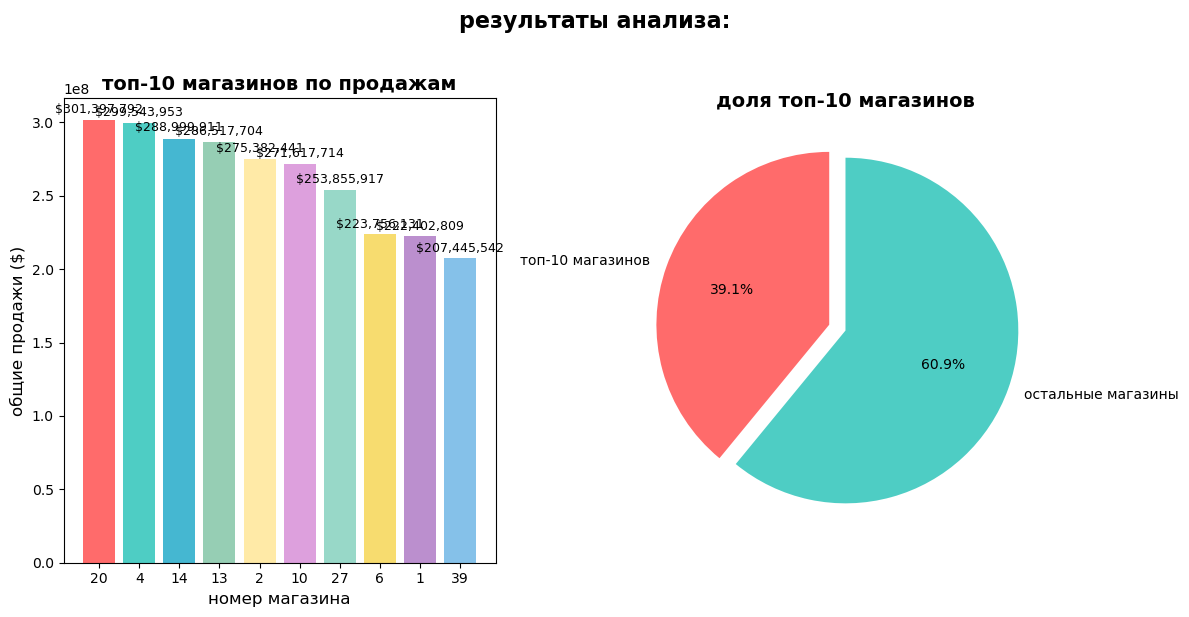

In [12]:
plt.figure(figsize=(12, 6))

#график 1: диаграмма топ-10
plt.subplot(1, 2, 1)
bars = plt.bar(top_10["Store"].astype(str), top_10["TotalSales"], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
                      '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9'])

plt.title('топ-10 магазинов по продажам', fontsize=14, fontweight='bold')
plt.xlabel('номер магазина', fontsize=12)
plt.ylabel('общие продажи ($)', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

#график 2: доля топ-10 от общих продаж
plt.subplot(1, 2, 2)
labels = ['топ-10 магазинов', 'остальные магазины']
sizes = [top_10_sales, total_all_sales - top_10_sales]
colors = ['#FF6B6B', '#4ECDC4']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=(0.1, 0))
plt.title('доля топ-10 магазинов', fontsize=14, fontweight='bold')

plt.suptitle('результаты анализа:', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()